# BÀI TẬP VỀ NHÀ

# Dự báo chuỗi thời gian bằng RNN

## Mô tả bài toán

Trong buổi học trên lớp, chúng ta đã làm quen với bài toán dự báo chuỗi thời gian bằng mô hình RNN trên dữ liệu sóng sin đơn giản.  
Để hiểu sâu hơn về cách hoạt động của mô hình và rèn luyện kỹ năng xử lý dữ liệu chuỗi, ở bài tập này em sẽ xây dựng một mô hình dự báo trên **dữ liệu đa biến**, phức tạp hơn so với ví dụ trên lớp.

Mục tiêu của bài là sử dụng các giá trị trong quá khứ của nhiều đặc trưng để dự đoán giá trị của biến mục tiêu ở thời điểm tiếp theo.

## Mục tiêu cần đạt

Sau khi hoàn thành bài tập, em cần:

- Biết cách tạo và xử lý dữ liệu chuỗi thời gian.
- Biết cách chuẩn hóa dữ liệu trước khi đưa vào mô hình.
- Biết cách tạo các chuỗi con phục vụ huấn luyện.
- Xây dựng được mô hình RNN bằng PyTorch.
- Thực hiện huấn luyện, đánh giá và trực quan hóa kết quả.

## Dữ liệu sử dụng

Khác với ví dụ trên lớp chỉ có một chuỗi sin, trong bài này dữ liệu gồm nhiều đặc trưng hơn:

- `feature_1`: chuỗi dạng sin
- `feature_2`: chuỗi dạng cos
- `feature_3`: chuỗi có xu hướng tăng nhẹ kèm nhiễu
- `target`: biến mục tiêu được tạo từ tổ hợp của các đặc trưng trên

In [13]:
#phần 1
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pollution.csv"

df = pd.read_csv(url)

print(df.columns)


# chọn 3 feature
data = df[['pm2.5','DEWP','TEMP']].values


# xử lý NaN
data = pd.DataFrame(data).fillna(method="bfill").values


# chuẩn hóa [0,1]
scaler = MinMaxScaler()

data_scaled = scaler.fit_transform(data)


# tạo sequence
def create_sequences(data, seq_length=20):

    X = []
    y = []

    for i in range(len(data)-seq_length):

        X.append(data[i:i+seq_length])

        y.append(data[i+seq_length,0])

    return np.array(X), np.array(y)


seq_length = 20

X, y = create_sequences(data_scaled, seq_length)


# chia dữ liệu
train_size = int(len(X)*0.7)

val_size = int(len(X)*0.15)


X_train = X[:train_size]
y_train = y[:train_size]

X_val = X[train_size:train_size+val_size]
y_val = y[train_size:train_size+val_size]

X_test = X[train_size+val_size:]
y_test = y[train_size+val_size:]


# tensor
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)

X_val = torch.tensor(X_val, dtype=torch.float32)
y_val = torch.tensor(y_val, dtype=torch.float32)

X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)


print("Train:", X_train.shape)
print("Val:", X_val.shape)
print("Test:", X_test.shape)

Index(['No', 'year', 'month', 'day', 'hour', 'pm2.5', 'DEWP', 'TEMP', 'PRES',
       'cbwd', 'Iws', 'Is', 'Ir'],
      dtype='object')
Train: torch.Size([30662, 20, 3])
Val: torch.Size([6570, 20, 3])
Test: torch.Size([6572, 20, 3])


/tmp/ipykernel_2556/1860633855.py:14: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data = pd.DataFrame(data).fillna(method="bfill").values


epoch: 0 train loss: 0.05916306748986244 val loss: 0.0485149584710598
epoch: 20 train loss: 0.008666259236633778 val loss: 0.009225995279848576
epoch: 40 train loss: 0.006439908407628536 val loss: 0.007323873694986105
epoch: 60 train loss: 0.005074917338788509 val loss: 0.005735890939831734
epoch: 80 train loss: 0.003084499854594469 val loss: 0.0033440280240029097
epoch: 100 train loss: 0.0018391909543424845 val loss: 0.0018539875745773315
epoch: 120 train loss: 0.0015784009592607617 val loss: 0.0015739588998258114
epoch: 140 train loss: 0.0014369215350598097 val loss: 0.0014166025212034583


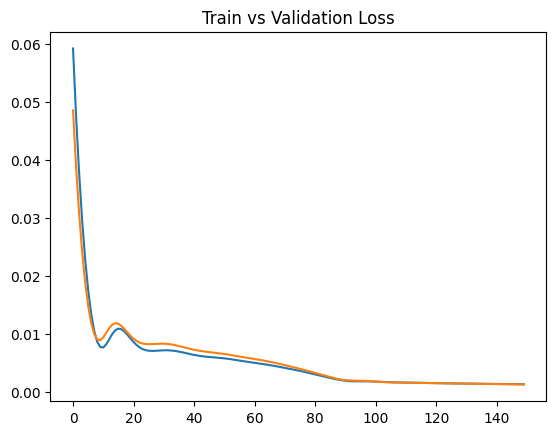

In [14]:
#phần 2

import torch
import torch.nn as nn
import matplotlib.pyplot as plt


# model
class RNNModel(nn.Module):

    def __init__(self, input_size=3, hidden_size=32, output_size=1):

        super().__init__()

        self.rnn = nn.RNN(
            input_size,
            hidden_size,
            batch_first=True
        )

        self.fc = nn.Linear(
            hidden_size,
            output_size
        )


    def forward(self, x):

        out,_ = self.rnn(x)

        out = out[:,-1,:]

        return self.fc(out)



# tạo model
model = RNNModel()


# loss
criterion = nn.MSELoss()


# optimizer
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)


# train
epochs = 150

train_losses = []
val_losses = []


for epoch in range(epochs):

    model.train()

    pred = model(X_train)

    loss = criterion(
        pred.squeeze(),
        y_train
    )


    optimizer.zero_grad()

    loss.backward()

    optimizer.step()


    model.eval()

    with torch.no_grad():

        val_pred = model(X_val)

        val_loss = criterion(
            val_pred.squeeze(),
            y_val
        )


    train_losses.append(loss.item())

    val_losses.append(val_loss.item())


    if epoch % 20 == 0:

        print(
            "epoch:", epoch,
            "train loss:", loss.item(),
            "val loss:", val_loss.item()
        )


# plot loss
plt.plot(train_losses)

plt.plot(val_losses)

plt.title("Train vs Validation Loss")

plt.show()

MSE: 0.0008946208981797099
MAE: 0.01944958046078682


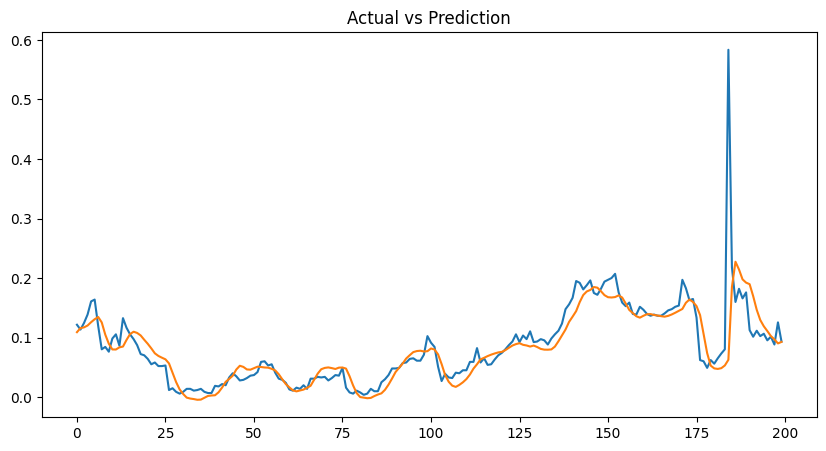

In [15]:
#phần 3
from sklearn.metrics import mean_squared_error, mean_absolute_error


model.eval()

with torch.no_grad():

    test_pred = model(X_test).squeeze().numpy()


y_true = y_test.numpy()


# metrics
mse = mean_squared_error(
    y_true,
    test_pred
)

mae = mean_absolute_error(
    y_true,
    test_pred
)


print("MSE:", mse)

print("MAE:", mae)


# plot prediction
plt.figure(figsize=(10,5))

plt.plot(y_true[:200])

plt.plot(test_pred[:200])

plt.title("Actual vs Prediction")

plt.show()

Best config: 10 32


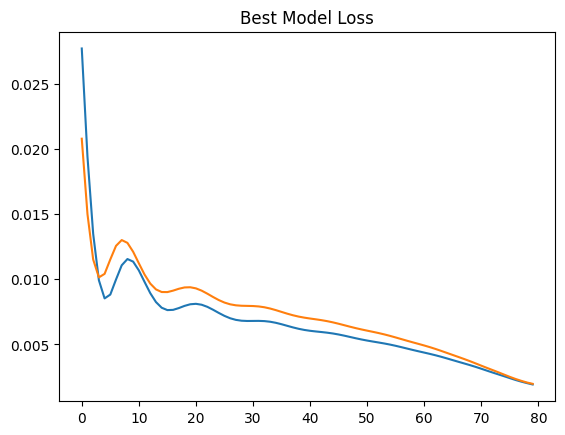

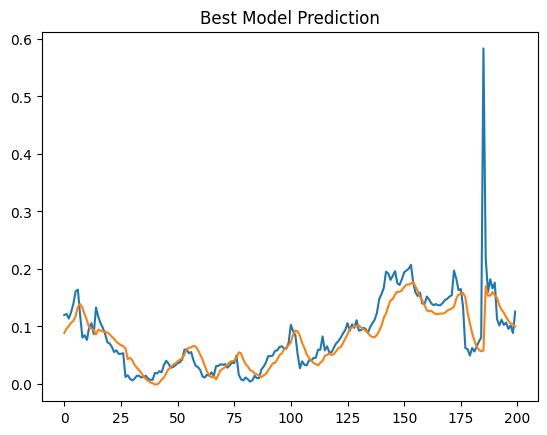

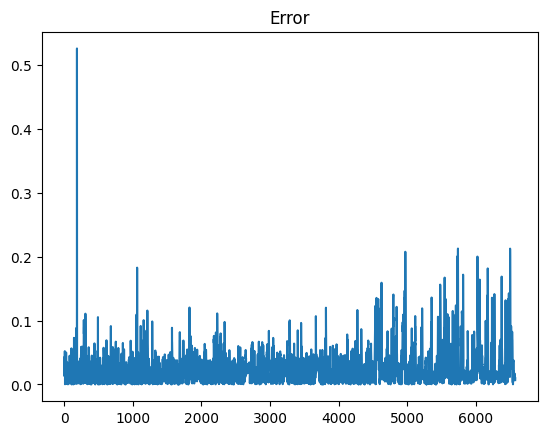

In [16]:
#phần 4

seq_list = [10,20]

hidden_list = [16,32]

epochs = 80


results = []


for seq_length in seq_list:

    X, y = create_sequences(data_scaled, seq_length)


    train_size = int(len(X)*0.7)

    val_size = int(len(X)*0.15)


    X_train = torch.tensor(X[:train_size], dtype=torch.float32)
    y_train = torch.tensor(y[:train_size], dtype=torch.float32)

    X_val = torch.tensor(X[train_size:train_size+val_size], dtype=torch.float32)
    y_val = torch.tensor(y[train_size:train_size+val_size], dtype=torch.float32)

    X_test = torch.tensor(X[train_size+val_size:], dtype=torch.float32)
    y_test = torch.tensor(y[train_size+val_size:], dtype=torch.float32)


    for hidden in hidden_list:

        model = RNNModel(hidden_size=hidden)

        criterion = nn.MSELoss()

        optimizer = torch.optim.Adam(model.parameters(), lr=0.001)


        train_losses = []

        val_losses = []


        for epoch in range(epochs):

            model.train()

            pred = model(X_train)

            loss = criterion(pred.squeeze(), y_train)


            optimizer.zero_grad()

            loss.backward()

            optimizer.step()


            model.eval()

            with torch.no_grad():

                val_pred = model(X_val)

                val_loss = criterion(

                    val_pred.squeeze(),

                    y_val

                )


            train_losses.append(loss.item())

            val_losses.append(val_loss.item())



        # evaluate
        model.eval()

        with torch.no_grad():

            test_pred = model(X_test).squeeze().numpy()


        mse = mean_squared_error(

            y_test.numpy(),

            test_pred

        )


        results.append({

            "seq": seq_length,

            "hidden": hidden,

            "mse": mse,

            "train_loss": train_losses,

            "val_loss": val_losses,

            "pred": test_pred,

            "true": y_test.numpy()

        })


# model tốt nhất
best = min(results, key=lambda x: x["mse"])

print("Best config:", best["seq"], best["hidden"])


# plot loss
plt.plot(best["train_loss"])

plt.plot(best["val_loss"])

plt.title("Best Model Loss")

plt.show()


# plot prediction
plt.plot(best["true"][:200])

plt.plot(best["pred"][:200])

plt.title("Best Model Prediction")

plt.show()


# error plot
error = abs(best["true"] - best["pred"])

plt.plot(error)

plt.title("Error")

plt.show()